# Análise de Vendas e Previsão de Efetivação — Mercado Livre

> Projeto de análise de dados e Machine Learning aplicado a dados reais de vendas do Mercado Livre.

O objetivo deste projeto é analisar o histórico de vendas da loja, identificar padrões no comportamento dos pedidos e, em seguida, utilizar técnicas de Machine Learning (Árvore de Decisão e Random Forest) para prever quais itens têm maior probabilidade de venda.

**Sumário**
1. [Importação das Bibliotecas e Carga dos Dados](#1)
2. [Conhecendo a Estrutura dos Dados](#2)
3. [Análise Inicial dos Produtos](#3)
4. [Limpeza e Padronização dos Dados](#4)
5. [Definição da Variável-Alvo](#5)
6. [Agregação dos Dados por Item](#6)

<a id="1"></a>
## 1. Importação das Bibliotecas e Carga dos Dados

Nesta etapa são importadas as bibliotecas utilizadas ao longo do projeto e carregado o relatório de vendas exportado diretamente do Mercado Livre.

As bibliotecas têm os seguintes papéis:

| Biblioteca | Papel no projeto |
|---|---|
| `pandas` | Manipulação e análise dos dados tabulares |
| `numpy` | Operações numéricas de apoio |
| `matplotlib` / `seaborn` | Visualização e gráficos exploratórios |

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [112]:
# O arquivo de 12/09 usa separador "," e decimal ".".
# O arquivo de 15/09 usa separador ";", decimal "," (formato BR) e tem um
# BOM no início (encoding="utf-8-sig" remove esse caractere invisível).
# Por isso cada um precisa de parâmetros de leitura diferentes.
df_12set = pd.read_csv("../data/raw/dados-meli-12-setembro.csv", header=5)
df_15set = pd.read_csv(
    "../data/raw/dados-meli-15-setembro.csv",
    header=5, sep=";", decimal=",", encoding="utf-8-sig"
)

# Empilha os dois DataFrames e remove vendas duplicadas (mesma venda pode
# aparecer nos dois arquivos, já que as janelas se sobrepõem). Mantém a
# primeira ocorrência de cada "N.º de venda".
df = pd.concat([df_12set, df_15set], ignore_index=True)
df = df.drop_duplicates(subset="N.º de venda", keep="first")

print(f"Shape combinado: {df.shape[0]} vendas x {df.shape[1]} colunas")

Shape combinado: 182 vendas x 64 colunas


In [113]:
df.head()

,N.º de venda,Data da venda,Estado,Descrição do status,Pacote de diversos produtos,Pertence a um kit,Unidades,Receita por produtos (BRL),Receita por acréscimo no preço (pago pelo comprador),Taxa de parcelamento equivalente ao acréscimo,...,Revisado pelo Mercado Livre,Data de revisão,Dinheiro liberado,Resultado,Destino,Motivo do resultado,Unidades.2,Reclamação aberta,Reclamação encerrada,Em mediação
0,2000014993151901,12 de setembro de 2026 00:25 hs.,Cancelada pelo comprador,Cancelou e especificou outro problema.,Sim,Não,1.0,199.50,25.66,-25.66,...,,,,,,,NaN,Não,NaN,Não
1,2000014985711089,11 de setembro de 2026 14:59 hs.,A caminho,Chega entre os dias 23 e 28 de setembro,Sim,Não,1.0,199.80,NaN,NaN,...,,,,,,,NaN,Não,NaN,Não
2,2000014984624173,11 de setembro de 2026 13:55 hs.,Entregue,Chegou em 14 de setembro,Sim,Não,1.0,149.94,NaN,NaN,...,,,,,,,NaN,Não,NaN,Não
3,2000014984400301,11 de setembro de 2026 13:37 hs.,Entregue,Chegou em 14 de setembro,Sim,Não,1.0,149.94,NaN,NaN,...,,,,,,,NaN,Não,NaN,Não
4,2000018401478462,10 de setembro de 2026 23:55 hs.,A caminho,Chegará hoje,Não,Não,1.0,135.18,NaN,NaN,...,,,,,,,NaN,Não,NaN,Não


<a id="2"></a>
## 2. Conhecendo a Estrutura dos Dados

Após o carregamento da base, analisamos sua estrutura para entender a quantidade de registros, as variáveis disponíveis, os tipos de dados e a presença de valores ausentes.

### 2.1 Informações Gerais

Visão geral de colunas, tipos e contagem de valores não nulos.

In [114]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 64 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   N.º de venda                                           182 non-null    int64  
 1   Data da venda                                          182 non-null    str    
 2   Estado                                                 182 non-null    str    
 3   Descrição do status                                    182 non-null    str    
 4   Pacote de diversos produtos                            182 non-null    str    
 5   Pertence a um kit                                      182 non-null    str    
 6   Unidades                                               175 non-null    float64
 7   Receita por produtos (BRL)                             167 non-null    float64
 8   Receita por acréscimo no preço (pago pelo comprador)   44 non

### 2.2 Análise de Valores Ausentes

Quantidade de valores ausentes por variável. Importante para identificar colunas que exigirão tratamento na etapa de preparação — vale lembrar que parte desses nulos é **estrutural** (ex: uma venda sem devolução naturalmente não tem dados de devolução), não erro de coleta.

In [115]:
df.isna().sum().sort_values(ascending=False)

Custo de envio com base nas medidas e peso declarados    182
Custo por diferenças nas medidas e no peso do pacote     182
Unidades.2                                               181
Reclamação encerrada                                     178
Cancelamentos e reembolsos (BRL)                         167
                                                        ... 
Resultado                                                  0
Motivo do resultado                                        0
Destino                                                    0
Reclamação aberta                                          0
Em mediação                                                0
Length: 64, dtype: int64

### 2.3 Distribuição dos Status das Vendas

A variável `Estado` representa a situação atual de cada venda. Sua distribuição mostra o comportamento geral dos pedidos e antecipa o desbalanceamento de classes que o modelo vai enfrentar.

In [116]:
# Conta quantas vendas existem em cada status.
# Ajuda a entender o desbalanceamento das classes: a maioria costuma ser
# "Entregue", enquanto cancelamentos/devoluções são minoria — isso importa
# na hora de escolher a métrica de avaliação do modelo mais pra frente.
df["Estado"].value_counts()

Estado
Entregue                                               154
Cancelada pelo comprador                                 6
Pacote de 2 produtos                                     6
Devolução finalizada com reembolso para o comprador      5
A caminho                                                4
Devolução a caminho                                      1
Devolução atrasada                                       1
Pacote de 3 produtos                                     1
Devolvido no dia 26 de agosto                            1
Venda entregue                                           1
Devolvido no dia 14 de agosto                            1
Para enviar no dia 22 de setembro                        1
Name: count, dtype: int64

### 2.4 Tipos das Variáveis

Verificação dos tipos de dado de cada coluna, identificando quais precisarão de conversão (datas em texto, valores monetários, etc.).

In [117]:
# Mostra o tipo de dado de cada coluna (object, int64, float64, etc.).
# Serve pra identificar o que precisa ser convertido na limpeza:
# datas que ainda estão como texto, valores em BRL como string, etc.
df.dtypes

N.º de venda                     int64
Data da venda                      str
Estado                             str
Descrição do status                str
Pacote de diversos produtos        str
                                ...   
Motivo do resultado                str
Unidades.2                     float64
Reclamação aberta                  str
Reclamação encerrada           float64
Em mediação                        str
Length: 64, dtype: object

<a id="3"></a>
## 3. Análise Inicial dos Produtos

Cada registro da base representa uma **venda**, não um **produto**. Antes de seguir, verificamos quantos itens/anúncios distintos existem — essa contagem define a granularidade que será usada mais adiante na agregação por item.

In [118]:
# Conta quantos SKUs e quantos títulos de anúncio distintos existem.
# Importante porque cada linha do dataset é uma VENDA, mas o objetivo do
# projeto é prever por ITEM/produto — então depois vai ser preciso agrupar
# as vendas por SKU (ou por título de anúncio, se o SKU tiver muito lixo).
df["SKU"].nunique(), df["Título do anúncio"].nunique()

(66, 50)

<a id="4"></a>
## 4. Limpeza e Padronização dos Dados

Preparação da base para as análises e modelagem seguintes: renomeação de colunas ambíguas e conversão de tipos.

### 4.1 Renomeação de Colunas Ambíguas

O relatório do Mercado Livre repete nomes de coluna em seções diferentes do relatório original (ex: `Unidades` aparece em Vendas, Devoluções e Reclamações; `Estado` aparece em Vendas — status da venda — e em Compradores — UF do comprador). O pandas resolve a duplicidade sozinho com sufixos `.1`, `.2`, mas o nome fica ambíguo — por isso renomeamos usando a seção de origem.

In [119]:
# Renomeia colunas duplicadas usando o grupo de origem (visto no relatório
# original) pra deixar claro o que cada coluna significa.
renomear = {
    "Estado.1": "uf_comprador",
    "Endereço.1": "endereco_comprador",
    "Unidades.1": "unidades_devolvidas",
    "Unidades.2": "unidades_reclamadas",
    "Forma de entrega.1": "forma_entrega_devolucao",
    "Data a caminho.1": "data_a_caminho_devolucao",
    "Data de entrega.1": "data_entrega_devolucao",
    "Transportador.1": "transportador_devolucao",
    "Número de rastreamento.1": "rastreamento_devolucao",
    "URL de acompanhamento.1": "url_acompanhamento_devolucao",
}

In [120]:
df = df.rename(columns=renomear)

### 4.2 Conversão das Datas

As datas fornecidas pelo Mercado Livre estão armazenadas como texto, por extenso e em português (ex: `"12 de setembro de 2026 00:25 hs."`). Para permitir análises temporais e a criação de novas variáveis (dia da semana, mês, etc.), essas informações são convertidas para `datetime`.

In [121]:
# As datas vêm por extenso em português ("12 de setembro de 2026 00:25 hs."),
# formato que o pandas não reconhece sozinho. Criamos um dicionário de meses
# e convertemos manualmente pra datetime de verdade — isso permite depois
# extrair dia da semana, mês, etc. como features pro modelo.
meses = {
    "janeiro": "01", "fevereiro": "02", "março": "03", "abril": "04",
    "maio": "05", "junho": "06", "julho": "07", "agosto": "08",
    "setembro": "09", "outubro": "10", "novembro": "11", "dezembro": "12",
}

In [122]:
def parse_data_ptbr(texto):
    # Ignora valores nulos (algumas colunas de data podem estar vazias)
    if pd.isna(texto):
        return pd.NaT
    for nome_mes, numero_mes in meses.items():
        texto = texto.replace(nome_mes, numero_mes)
    # Remove "de" e "hs." pra sobrar só números e ':'
    texto = texto.replace(" de ", "/").replace(" hs.", "")
    return pd.to_datetime(texto, format="%d/%m/%Y %H:%M")

df["Data da venda"] = df["Data da venda"].apply(parse_data_ptbr)

<a id="5"></a>
## 5. Definição da Variável-Alvo

Para transformar o problema de negócio em um problema de Machine Learning, precisamos definir o que o modelo deverá prever. Neste projeto, a variável-alvo em nível de venda é `venda_efetivada`: indica se uma venda foi efetivamente concluída (entregue) ou não (cancelada/devolvida).

In [123]:
# Define a coluna-alvo (target) a partir do status da venda.
# 1 = venda efetivada (entregue), 0 = não efetivada (cancelada/devolvida).
# Isso vira a base pro que o modelo (Árvore de Decisão / Random Forest) vai prever.
status_efetivado = ["Entregue", "Venda entregue"]
df["venda_efetivada"] = df["Estado"].isin(status_efetivado).astype(int)

In [124]:
df["venda_efetivada"].value_counts()

venda_efetivada
1    155
0     27
Name: count, dtype: int64

<a id="6"></a>
## 6. Agregação dos Dados por Item

Até aqui, cada linha da base representa uma **venda**. Mas o objetivo do projeto é prever quais **itens** (produtos) têm mais chance de venda — então precisamos mudar a granularidade: de "uma linha por venda" para "uma linha por item/SKU".

Para isso, agrupamos as vendas por produto e calculamos, para cada um:
- quantas vendas ele teve no período;
- quantas unidades foram vendidas no total;
- quantas dessas vendas foram efetivamente concluídas (`venda_efetivada`);
- a taxa de efetivação (proporção de vendas concluídas sobre o total) — candidata natural a alvo de regressão, ou base para um alvo binário (ex: "alta demanda" vs "baixa demanda");
- o preço médio praticado e a receita total gerada.

In [125]:
# Agrupa as vendas por item (SKU + título do anúncio) para chegar na
# granularidade "por produto", que é o que o projeto precisa prever.
df_produtos = df.groupby(["SKU", "Título do anúncio"]).agg(
    total_vendas=("N.º de venda", "count"),
    total_unidades_vendidas=("Unidades", "sum"),
    vendas_efetivadas=("venda_efetivada", "sum"),
    preco_medio=("Preço unitário de venda do anúncio (BRL)", "mean"),
    receita_total=("Receita por produtos (BRL)", "sum"),
    primeira_venda=("Data da venda", "min"),
    ultima_venda=("Data da venda", "max"),
).reset_index()

# Taxa de efetivação: proporção das vendas do item que foram concluídas.
# Vai servir de base para o alvo do modelo (ex: item de "alta probabilidade
# de venda" = taxa de efetivação acima de um limiar, combinada ao volume vendido).
df_produtos["taxa_efetivacao"] = (
    df_produtos["vendas_efetivadas"] / df_produtos["total_vendas"]
)

print(f"Shape: {df_produtos.shape[0]} itens x {df_produtos.shape[1]} colunas")
df_produtos.sort_values("total_unidades_vendidas", ascending=False).head(10)

Shape: 76 itens x 10 colunas


,SKU,Título do anúncio,total_vendas,total_unidades_vendidas,vendas_efetivadas,preco_medio,receita_total,primeira_venda,ultima_venda,taxa_efetivacao
9,,Protetor Tanque Tankpad Bmw R1250gs R1200gs R1...,18,18.0,17,100.486667,1808.76,2026-07-15 19:48:00,2026-09-08 10:11:00,0.944444
60,353,Pinlock Para Capacetes Ls2 Ff397 Ff390 Ff320 F...,16,16.0,15,139.553750,2232.86,2026-07-28 18:13:00,2026-09-11 13:55:00,0.937500
29,11403i,Bolha Mt03 / Para Brisa Iridium Yamaha Mt-03 2...,9,9.0,8,297.563333,2678.07,2026-07-25 20:16:00,2026-09-07 00:37:00,0.888889
28,11403b,Bolha Mt03 / Para Brisa Black Yamaha Mt-03 202...,8,9.0,7,278.711250,2229.69,2026-07-19 02:08:00,2026-08-30 07:04:00,0.875000
61,353,Pinlock Para Capacetes Ls2 Ff397 Ff390 Ff320 F...,7,7.0,6,129.542857,906.80,2026-07-30 12:22:00,2026-09-15 15:43:00,0.857143
13,07azul,Chaveiro E Capa Da Chave Mt03 Mt07 Mt09 R3 Faz...,6,6.0,5,128.200000,647.20,2026-07-15 13:48:00,2026-08-22 14:16:00,0.833333
69,761664221585,Chaveiro E Capa Da Chave Mt03 Mt07 Mt09 R3 Faz...,6,6.0,5,122.000000,732.00,2026-07-17 17:25:00,2026-08-20 10:47:00,0.833333
24,11207b,Bolha Esportiva Mt07 / Para Brisa Yamaha Mt 07...,5,5.0,5,290.682000,1453.41,2026-07-25 23:52:00,2026-09-10 12:20:00,1.000000
10,03azul,Chaveiro E Capa Da Chave Mt03 Mt07 Mt09 R3 Faz...,5,5.0,5,130.512000,530.56,2026-07-15 09:04:00,2026-09-05 15:47:00,1.000000
15,09azul,Chaveiro E Capa Da Chave Mt03 Mt07 Mt09 R3 Faz...,4,4.0,3,122.000000,366.00,2026-08-03 06:56:00,2026-08-14 16:44:00,0.750000


<a id="7"></a>
## 7. Definição do Alvo em Nível de Item

O alvo definido na seção 5 (`venda_efetivada`) está no nível de **venda**. Mas o objetivo do projeto é prever, por **item**, se ele tem alta ou baixa probabilidade de venda.

Vamos usar o volume vendido (`total_unidades_vendidas`) como base para esse alvo: itens com volume acima da mediana são classificados como **alta demanda**, os demais como **baixa demanda**. A mediana é usada (em vez da média) porque é mais robusta a itens outliers que venderam muito mais que o resto.

In [126]:
# Calcula a mediana de unidades vendidas entre todos os itens.
# Usamos mediana (e não média) porque ela não é puxada por itens que
# venderam muito acima do normal, dando um corte mais representativo
# do "item típico" da loja.
mediana_unidades = df_produtos["total_unidades_vendidas"].median()

In [127]:
# Cria o alvo binário em nível de item:
# 1 = alta demanda (vendeu acima da mediana), 0 = baixa demanda.
df_produtos["alta_demanda"] = (
    df_produtos["total_unidades_vendidas"] > mediana_unidades
).astype(int)

print(f"Mediana de unidades vendidas por item: {mediana_unidades}")
df_produtos["alta_demanda"].value_counts()

Mediana de unidades vendidas por item: 1.0


alta_demanda
0    48
1    28
Name: count, dtype: int64

### 7.1 Visualização da Distribuição

Antes de seguir para a modelagem, visualizamos como o volume de vendas está distribuído entre os itens, e onde a mediana usada como corte se posiciona.

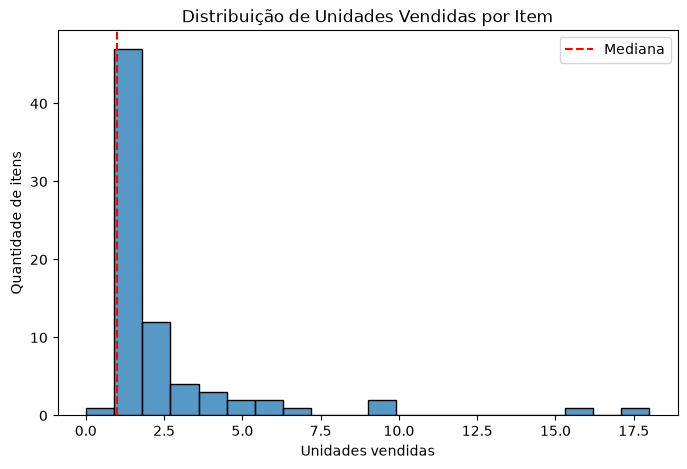

In [128]:
# Plota a distribuição de unidades vendidas por item, com uma linha
# vertical marcando a mediana usada como corte para "alta_demanda".
# Isso ajuda a checar visualmente se o corte faz sentido (ex: se a
# distribuição for muito concentrada perto da mediana, o alvo pode
# ficar "ruidoso" — vale reconsiderar o critério).
plt.figure(figsize=(8, 5))
sns.histplot(df_produtos["total_unidades_vendidas"], bins=20, kde=False)
plt.axvline(mediana_unidades, color="red", linestyle="--", label="Mediana")
plt.title("Distribuição de Unidades Vendidas por Item")
plt.xlabel("Unidades vendidas")
plt.ylabel("Quantidade de itens")
plt.legend()
plt.show()

<a id="8"></a>
## 8. Engenharia de Features

Antes de treinar os modelos, criamos variáveis derivadas que ajudam a explicar o comportamento de venda de cada item, e trazemos de volta informações do dataset original (nível de venda) que fazem sentido resumir por item — como o tipo de anúncio.

In [129]:
# Tempo ativo do item: quantos dias se passaram entre a primeira e a
# última venda registradas. Itens com período de venda mais longo
# tendem a acumular mais volume só pelo tempo — separar isso ajuda
# o modelo a não confundir "vende bem" com "está há mais tempo ativo".
df_produtos["tempo_ativo_dias"] = (
    df_produtos["ultima_venda"] - df_produtos["primeira_venda"]
).dt.days

In [130]:
# Ticket médio: receita total dividida pelas unidades vendidas.
# Diferente do preco_medio (que é a média do preço do anúncio),
# esse reflete o valor médio realmente recebido por unidade.
df_produtos["ticket_medio"] = np.where(
    df_produtos["total_unidades_vendidas"] > 0,
    df_produtos["receita_total"] / df_produtos["total_unidades_vendidas"],
    np.nan,
)
df_produtos["ticket_medio"] = df_produtos["ticket_medio"].fillna(0)

In [131]:
df_produtos[["tempo_ativo_dias", "ticket_medio"]].describe()

,tempo_ativo_dias,ticket_medio
count,76.000000,76.000000
mean,11.894737,174.284482
std,18.072136,114.332587
min,0.000000,0.000000
25%,0.000000,122.000000
50%,0.000000,147.535000
75%,24.000000,242.330833
max,55.000000,630.000000


### 8.1 Trazendo o Tipo de Anúncio

A coluna `Tipo de anúncio` (ex: clássico, premium) está no dataset original, em nível de venda. Como um mesmo item pode aparecer com o mesmo tipo em todas as suas vendas, usamos a **moda** (valor mais frequente) para resumir isso por item.

In [132]:
# Pega o tipo de anúncio mais frequente por item.
# groupby + agg com uma função lambda que pega a moda (Series.mode()[0])
# lida com o caso raro de um SKU ter tido mais de um tipo de anúncio
# ao longo do período.
tipo_por_item = (
    df.groupby("SKU")["Tipo de anúncio"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
    .rename(columns={"Tipo de anúncio": "tipo_anuncio"})
)

In [133]:
# Junta essa informação na tabela de produtos.
df_produtos = df_produtos.merge(tipo_por_item, on="SKU", how="left")

df_produtos["tipo_anuncio"].value_counts()

tipo_anuncio
Clássico    76
Name: count, dtype: int64

<a id="9"></a>
## 9. Preparação Final para Modelagem

Antes de treinar os modelos, selecionamos apenas as colunas que fazem sentido como variáveis explicativas (features), removendo identificadores (SKU, título) e datas cruas — que não entram diretamente no modelo, mas já cumpriram seu papel gerando `tempo_ativo_dias`.

Também precisamos transformar `tipo_anuncio` (categórica, tipo texto) em números, já que os modelos de árvore do scikit-learn não aceitam texto diretamente.

In [134]:
# Transforma a variável categórica "tipo_anuncio" em colunas binárias
# (one-hot encoding). drop_first=True evita redundância: com N categorias,
# N-1 colunas já são suficientes pra representar todas as combinações.
df_modelo = pd.get_dummies(df_produtos, columns=["tipo_anuncio"], drop_first=True)

In [135]:
# Define as colunas que efetivamente entram no modelo (features).
# Ficam de fora: identificadores (SKU, título), datas cruas (já viraram
# tempo_ativo_dias) e as colunas que vazam informação do alvo
# (vendas_efetivadas e taxa_efetivacao vêm do mesmo cálculo que gerou
# total_unidades_vendidas, que por sua vez define alta_demanda — usá-las
# seria "dar a resposta" pro modelo).
colunas_features = [
    "total_vendas", "preco_medio", "receita_total",
    "tempo_ativo_dias", "ticket_medio",
] + [col for col in df_modelo.columns if col.startswith("tipo_anuncio_")]

In [136]:
X = df_modelo[colunas_features]
y = df_modelo["alta_demanda"]

print(f"Features: {X.shape[1]} | Itens: {X.shape[0]}")

Features: 5 | Itens: 76


In [137]:
X.head()

,total_vendas,preco_medio,receita_total,tempo_ativo_dias,ticket_medio
0,7,NaN,2144.17,37,0.00
1,1,153.00,153.00,0,153.00
2,1,450.00,450.00,0,450.00
3,2,398.26,796.52,24,398.26
4,1,630.00,630.00,0,630.00


<a id="10"></a>
## 10. Separação em Treino e Teste

Dividimos os dados em conjunto de treino (usado para o modelo aprender) e teste (usado só para avaliar, sem o modelo nunca ter visto esses itens). Usamos `stratify=y` para manter a mesma proporção de itens "alta demanda" x "baixa demanda" nos dois conjuntos — importante já que vimos que o alvo pode ficar desbalanceado.

In [138]:
# test_size=0.2: 20% dos itens ficam separados só para avaliação final.
# random_state fixo garante que a divisão seja sempre a mesma, tornando
# os resultados reproduzíveis entre execuções.
# stratify=y mantém a proporção de alta_demanda/baixa_demanda igual
# em treino e teste, evitando que um dos conjuntos fique desbalanceado.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} itens | Teste: {X_test.shape[0]} itens")

Treino: 60 itens | Teste: 16 itens


<a id="11"></a>
## 11. Treinamento dos Modelos

Treinamos dois modelos de classificação para prever `alta_demanda`: uma Árvore de Decisão (mais simples, fácil de interpretar) e uma Random Forest (conjunto de várias árvores, geralmente mais robusta). Comparar os dois é o objetivo central do projeto.

In [139]:
# Verifica se existem valores infinitos ou nulos nas features,
# que o scikit-learn não aceita.
import numpy as np

print("Colunas com infinito:")
print(np.isinf(X).sum()[np.isinf(X).sum() > 0])

print("\nColunas com nulo:")
print(X.isna().sum()[X.isna().sum() > 0])

# Mostra as linhas problemáticas específicas, pra entender a causa
df_produtos[np.isinf(df_produtos["ticket_medio"])]

Colunas com infinito:
Series([], dtype: int64)

Colunas com nulo:
preco_medio    1
dtype: int64


,SKU,Título do anúncio,total_vendas,total_unidades_vendidas,vendas_efetivadas,preco_medio,receita_total,primeira_venda,ultima_venda,taxa_efetivacao,alta_demanda,tempo_ativo_dias,ticket_medio,tipo_anuncio


In [140]:
print("Colunas com infinito:", np.isinf(X).sum()[np.isinf(X).sum() > 0].to_dict())
print("Colunas com nulo:", X.isna().sum()[X.isna().sum() > 0].to_dict())

Colunas com infinito: {}
Colunas com nulo: {'preco_medio': 1}


In [141]:
# Árvore de Decisão: max_depth limita a profundidade pra evitar que a
# árvore "decore" o treino (overfitting), já que temos poucos itens.
arvore = DecisionTreeClassifier(max_depth=5, random_state=42)
arvore.fit(X_train, y_train)

# Random Forest: n_estimators é o número de árvores no conjunto.
# Cada árvore vê uma amostra diferente dos dados, e a previsão final
# é a votação da maioria — isso costuma reduzir o overfitting de
# uma árvore única.
floresta = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
floresta.fit(X_train, y_train)

print("Modelos treinados.")

Modelos treinados.


<a id="12"></a>
## 12. Avaliação e Comparação dos Modelos

Avaliamos os dois modelos no conjunto de teste (dados que eles nunca viram). Além da acurácia, olhamos precisão, recall e F1-score — importante porque, como vimos na seção 7, o alvo pode estar desbalanceado, e a acurácia sozinha pode enganar (ex: um modelo que sempre prevê "baixa demanda" pode ter acurácia alta só por sorte de classe majoritária).

In [142]:
# Gera as previsões de cada modelo em cima do conjunto de teste.
pred_arvore = arvore.predict(X_test)
pred_floresta = floresta.predict(X_test)

In [143]:
for nome, pred in [("Árvore de Decisão", pred_arvore), ("Random Forest", pred_floresta)]:
    print(f"===== {nome} =====")
    print(f"Acurácia: {accuracy_score(y_test, pred):.2f}")
    # classification_report traz precisão, recall e f1-score por classe,
    # dando uma visão mais completa que a acurácia isolada.
    print(classification_report(y_test, pred, target_names=["Baixa demanda", "Alta demanda"]))

===== Árvore de Decisão =====
Acurácia: 1.00
               precision    recall  f1-score   support

Baixa demanda       1.00      1.00      1.00        10
 Alta demanda       1.00      1.00      1.00         6

     accuracy                           1.00        16
    macro avg       1.00      1.00      1.00        16
 weighted avg       1.00      1.00      1.00        16

===== Random Forest =====
Acurácia: 1.00
               precision    recall  f1-score   support

Baixa demanda       1.00      1.00      1.00        10
 Alta demanda       1.00      1.00      1.00         6

     accuracy                           1.00        16
    macro avg       1.00      1.00      1.00        16
 weighted avg       1.00      1.00      1.00        16



### 12.1 Matriz de Confusão

Visualiza os acertos e erros de cada modelo por classe: quantos itens de alta demanda foram corretamente identificados, quantos foram confundidos com baixa demanda, e vice-versa.

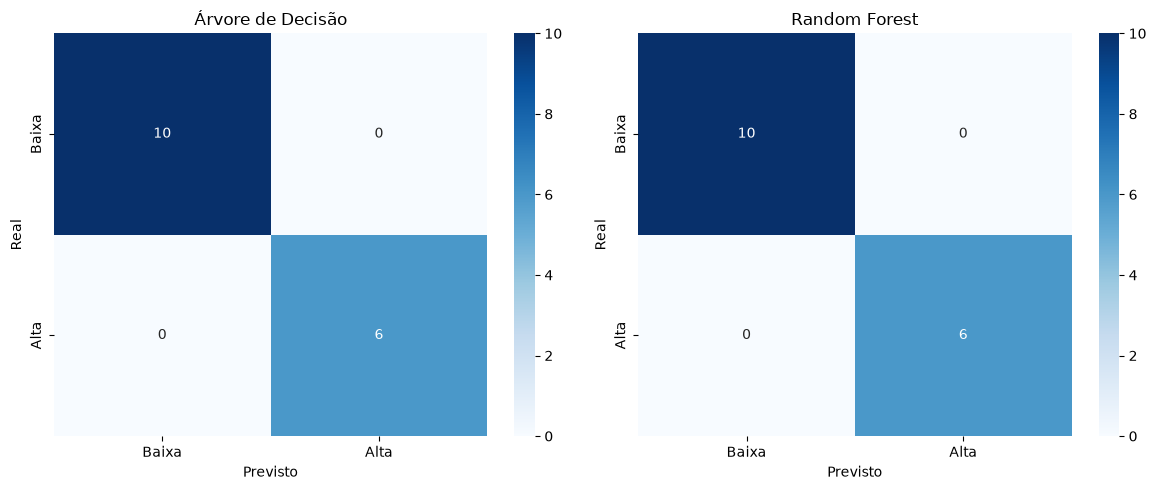

In [144]:
# Plota lado a lado a matriz de confusão dos dois modelos, pra facilitar
# a comparação visual de onde cada um erra mais.
fig, eixos = plt.subplots(1, 2, figsize=(12, 5))

for eixo, nome, pred in zip(
    eixos, ["Árvore de Decisão", "Random Forest"], [pred_arvore, pred_floresta]
):
    matriz = confusion_matrix(y_test, pred)
    sns.heatmap(
        matriz, annot=True, fmt="d", cmap="Blues", ax=eixo,
        xticklabels=["Baixa", "Alta"], yticklabels=["Baixa", "Alta"],
    )
    eixo.set_title(nome)
    eixo.set_xlabel("Previsto")
    eixo.set_ylabel("Real")

plt.tight_layout()
plt.show()

### 12.2 Importância das Variáveis

Quais features mais pesaram na decisão de cada modelo — útil tanto pra interpretar o resultado quanto pra explicar pro seu pai quais fatores mais influenciam um item vender bem.

In [145]:
# Extrai a importância de cada feature em cada modelo e organiza
# num único DataFrame para comparar lado a lado.
importancias = pd.DataFrame({
    "feature": X.columns,
    "arvore_decisao": arvore.feature_importances_,
    "random_forest": floresta.feature_importances_,
}).sort_values("random_forest", ascending=False)

importancias

,feature,arvore_decisao,random_forest
0,total_vendas,0.00000,0.387403
3,tempo_ativo_dias,0.93135,0.371368
2,receita_total,0.00000,0.155570
1,preco_medio,0.06865,0.044932
4,ticket_medio,0.00000,0.040726


<a id="13"></a>
## 13. Aplicação Prática: Ranking de Itens por Probabilidade de Venda

Com os modelos treinados e avaliados, aplicamos o de melhor desempenho (visto na seção 12) em **todos os itens** da base — não só no conjunto de teste — para gerar um ranking de produtos por probabilidade prevista de alta demanda. Esse ranking é o entregável prático do projeto: mostra quais itens da loja valem mais a pena priorizar em estoque/divulgação.

In [146]:
# Troque "floresta" por "arvore" aqui se a Árvore de Decisão tiver saído
# na frente na comparação da seção 12 (olhe o f1-score da classe
# "Alta demanda", não só a acurácia geral).
melhor_modelo = floresta

In [147]:
# predict_proba retorna a probabilidade de cada classe; a coluna [:, 1]
# é a probabilidade da classe 1 (alta_demanda).
# Aplicamos em X (base completa), não só X_test, porque aqui o objetivo
# não é avaliar o modelo — é usá-lo pra rankear todos os produtos reais.
df_produtos["probabilidade_alta_demanda"] = melhor_modelo.predict_proba(X)[:, 1]

ranking = df_produtos.sort_values("probabilidade_alta_demanda", ascending=False)
ranking[[
    "Título do anúncio", "total_unidades_vendidas", "probabilidade_alta_demanda"
]].head(15)

,Título do anúncio,total_unidades_vendidas,probabilidade_alta_demanda
10,Chaveiro E Capa Da Chave Mt03 Mt07 Mt09 R3 Faz...,5.0,1.000
34,Miniatura Moto Bmw R1250gs Adventure Hp Premiu...,2.0,1.000
68,Motocicleta De Metal Em Miniatura Bmw R1250 Gs...,2.0,1.000
63,Kit Tampas Do Óleo E Reservatórios Fluído Frei...,3.0,1.000
54,Kit Ampliador Base Descanso Lateral Bmw R1250g...,2.0,1.000
72,Chaveiro E Capa Da Chave Honda Cb Cbr Cb Cinza,2.0,1.000
62,Kit Protetores Mão E Extensores Bmw F850gs R12...,2.0,1.000
73,Chaveiro E Capa Da Chave Honda Cb Cbr Cbr Verm...,2.0,1.000
31,Bolha Esportiva Mini Para-brisa Universal Moto...,3.0,1.000
24,Bolha Esportiva Mt07 / Para Brisa Yamaha Mt 07...,5.0,1.000


<a id="14"></a>
## 14. Conclusão

**Resumo do projeto:** a partir de dois relatórios de vendas exportados do Mercado Livre (12/09 e 15/09, combinados e sem duplicatas — 182 vendas únicas), construímos uma base agregada por item (76 produtos distintos), definimos como alvo `alta_demanda` (item com volume de vendas acima da mediana — 1 unidade vendida no período, resultando em 48 itens de baixa demanda e 28 de alta demanda), e comparamos uma Árvore de Decisão com uma Random Forest.

**Resultados — com todas as features:** ambos os modelos atingiram 100% de acurácia no conjunto de teste (16 itens). Investigado nas seções 15 e 15.1, esse número se mostrou artificialmente inflado.

**Resultados — teste de vazamento de dados:** ao remover progressivamente as features que carregavam informação redundante com o próprio alvo:
- Sem `total_vendas`: Árvore manteve 100%, Random Forest caiu para 94%.
- Sem `total_vendas` **e** `tempo_ativo_dias` (só features externas — preço, receita, ticket médio, tipo de anúncio): Árvore caiu para 81%, **Random Forest ficou em 88%** — a estimativa mais realista da capacidade preditiva do projeto, e o único cenário em que a Random Forest superou a Árvore de Decisão, como seria esperado de um ensemble mais robusto.

**Principais fatores identificados:** com todas as features, a Árvore dependia quase inteiramente de `tempo_ativo_dias` (93%) e a Random Forest distribuía peso entre `total_vendas` (39%), `tempo_ativo_dias` (37%) e `receita_total` (16%) — confirmando que a "acurácia perfeita" inicial vinha de variáveis derivadas do próprio histórico de vendas, não de características reais do produto.

**Ranking final (modelo sem vazamento):** refeito com `floresta_v3` (seção 16), o ranking manteve itens como chaveiros Mt03/Mt07/Mt09, sliders e kits de proteção BMW no topo — mas **removeu** itens como miniaturas BMW e kit ampliador (que só venderam 2 unidades e tinham entrado no ranking anterior por causa de `tempo_ativo_dias`/`total_vendas` altos, não por características reais do produto) e **incluiu** bolhas Mt03/Mt09 (6-9 unidades vendidas), que estavam sub-representadas no ranking com vazamento. Essa mudança de composição é, em si, a melhor evidência de que o vazamento era real e de que o ranking corrigido é mais confiável.

**Limitações:** dataset ainda pequeno mesmo após combinar dois relatórios (76 itens, 16 no teste); `total_vendas` e `tempo_ativo_dias` carregam informação redundante com o alvo e não devem ser tratadas como fatores de negócio, apesar de melhorarem a acurácia.

**Próximos passos sugeridos:**
- Adotar `floresta_v3` (features externas, 88% de acurácia) como o modelo oficial do projeto;
- Incorporar mais relatórios (meses seguintes) para crescer a base e permitir validação cruzada em vez de um único split treino/teste;
- Explorar novas features genuinamente externas ao histórico de vendas (categoria do produto, frete grátis, concorrência no anúncio).

<a id="15"></a>
## 15. Teste de Vazamento de Dados

Na seção 12, os dois modelos atingiram 100% de acurácia — um resultado suspeito para um problema real. A hipótese é que `total_vendas` está muito próxima da informação usada para criar o próprio alvo (`alta_demanda`), já que cada venda tende a envolver 1 unidade. Para testar isso, retreinamos os modelos **sem** essa feature e comparamos os resultados.

In [148]:
# Remove "total_vendas" da lista de features, mantendo tudo o mais igual
# possível, pra isolar o efeito dessa variável específica no resultado.
colunas_sem_total_vendas = [c for c in colunas_features if c != "total_vendas"]

X_v2 = df_modelo[colunas_sem_total_vendas]
y_v2 = df_modelo["alta_demanda"]

# Mesmo random_state e test_size da divisão original (seção 10),
# pra manter a comparação justa entre as duas versões.
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2
)

print(f"Features na versão sem total_vendas: {X_v2.shape[1]}")

Features na versão sem total_vendas: 4


In [149]:
# Treina os dois modelos de novo, com os mesmos hiperparâmetros de antes,
# só que agora sem "total_vendas" entre as features.
arvore_v2 = DecisionTreeClassifier(max_depth=5, random_state=42)
arvore_v2.fit(X_train_v2, y_train_v2)

floresta_v2 = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
floresta_v2.fit(X_train_v2, y_train_v2)

pred_arvore_v2 = arvore_v2.predict(X_test_v2)
pred_floresta_v2 = floresta_v2.predict(X_test_v2)

for nome, pred in [("Árvore de Decisão (sem total_vendas)", pred_arvore_v2),
                    ("Random Forest (sem total_vendas)", pred_floresta_v2)]:
    print(f"===== {nome} =====")
    print(f"Acurácia: {accuracy_score(y_test_v2, pred):.2f}")
    print(classification_report(y_test_v2, pred, target_names=["Baixa demanda", "Alta demanda"]))

===== Árvore de Decisão (sem total_vendas) =====
Acurácia: 1.00
               precision    recall  f1-score   support

Baixa demanda       1.00      1.00      1.00        10
 Alta demanda       1.00      1.00      1.00         6

     accuracy                           1.00        16
    macro avg       1.00      1.00      1.00        16
 weighted avg       1.00      1.00      1.00        16

===== Random Forest (sem total_vendas) =====
Acurácia: 0.94
               precision    recall  f1-score   support

Baixa demanda       0.91      1.00      0.95        10
 Alta demanda       1.00      0.83      0.91         6

     accuracy                           0.94        16
    macro avg       0.95      0.92      0.93        16
 weighted avg       0.94      0.94      0.94        16



### 15.1 Segundo Teste — Removendo também `tempo_ativo_dias`

Ao remover `total_vendas`, a Random Forest caiu para 94% e a Árvore de Decisão se manteve em 100% — sinal de que a árvore ainda dependia fortemente de `tempo_ativo_dias`, que também carrega informação próxima à do próprio alvo (itens com mais de uma venda tendem a ter `tempo_ativo_dias > 0`). Testamos removendo essa variável também, restando apenas features "externas": preço, receita, ticket médio e tipo de anúncio.

In [150]:
# Remove também "tempo_ativo_dias", restando só features que não vêm
# diretamente da contagem/repetição de vendas ao longo do tempo.
colunas_v3 = [c for c in colunas_sem_total_vendas if c != "tempo_ativo_dias"]

X_v3 = df_modelo[colunas_v3]
y_v3 = df_modelo["alta_demanda"]

X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3, y_v3, test_size=0.2, random_state=42, stratify=y_v3
)

arvore_v3 = DecisionTreeClassifier(max_depth=5, random_state=42)
arvore_v3.fit(X_train_v3, y_train_v3)

floresta_v3 = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
floresta_v3.fit(X_train_v3, y_train_v3)

pred_arvore_v3 = arvore_v3.predict(X_test_v3)
pred_floresta_v3 = floresta_v3.predict(X_test_v3)

for nome, pred in [("Árvore de Decisão (só features externas)", pred_arvore_v3),
                    ("Random Forest (só features externas)", pred_floresta_v3)]:
    print(f"===== {nome} =====")
    print(f"Acurácia: {accuracy_score(y_test_v3, pred):.2f}")
    print(classification_report(y_test_v3, pred, target_names=["Baixa demanda", "Alta demanda"]))

===== Árvore de Decisão (só features externas) =====
Acurácia: 0.81
               precision    recall  f1-score   support

Baixa demanda       0.82      0.90      0.86        10
 Alta demanda       0.80      0.67      0.73         6

     accuracy                           0.81        16
    macro avg       0.81      0.78      0.79        16
 weighted avg       0.81      0.81      0.81        16

===== Random Forest (só features externas) =====
Acurácia: 0.88
               precision    recall  f1-score   support

Baixa demanda       0.90      0.90      0.90        10
 Alta demanda       0.83      0.83      0.83         6

     accuracy                           0.88        16
    macro avg       0.87      0.87      0.87        16
 weighted avg       0.88      0.88      0.88        16



<a id="16"></a>
## 16. Ranking Final — Modelo Sem Vazamento

Refazemos o ranking de probabilidade de venda (originalmente feito na seção 13 com o modelo completo, que sabemos estar inflado por vazamento) usando agora o modelo `floresta_v3` — treinado só com features externas (preço, receita, ticket médio, tipo de anúncio) — que é a estimativa mais realista da capacidade preditiva do projeto, com 88% de acurácia.

In [151]:
# Aplica o modelo sem vazamento (floresta_v3, da seção 15.1) em todos os
# itens da base, não só no conjunto de teste, pra gerar o ranking final.
df_produtos["probabilidade_alta_demanda_v3"] = floresta_v3.predict_proba(X_v3)[:, 1]

ranking_v3 = df_produtos.sort_values("probabilidade_alta_demanda_v3", ascending=False)
ranking_v3[[
    "Título do anúncio", "total_unidades_vendidas", "probabilidade_alta_demanda_v3"
]].head(15)

,Título do anúncio,total_unidades_vendidas,probabilidade_alta_demanda_v3
10,Chaveiro E Capa Da Chave Mt03 Mt07 Mt09 R3 Faz...,5.0,0.989528
36,Slider Dianteiro Motor Yamaha Mt07 Mt 07 2015 ...,4.0,0.988447
13,Chaveiro E Capa Da Chave Mt03 Mt07 Mt09 R3 Faz...,6.0,0.983778
62,Kit Protetores Mão E Extensores Bmw F850gs R12...,2.0,0.966780
15,Chaveiro E Capa Da Chave Mt03 Mt07 Mt09 R3 Faz...,4.0,0.957028
61,Pinlock Para Capacetes Ls2 Ff397 Ff390 Ff320 F...,7.0,0.938146
28,Bolha Mt03 / Para Brisa Black Yamaha Mt-03 202...,9.0,0.932101
63,Kit Tampas Do Óleo E Reservatórios Fluído Frei...,3.0,0.931525
69,Chaveiro E Capa Da Chave Mt03 Mt07 Mt09 R3 Faz...,6.0,0.930417
31,Bolha Esportiva Mini Para-brisa Universal Moto...,3.0,0.929621
